In [2]:
import sys
print(sys.version)

3.10.20 (main, Mar 11 2026, 17:43:48) [Clang 20.1.8 ]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [4]:
df = pd.read_csv("loan_data.csv")
df.head()

,customer_id,income,credit_score,loan_amount,employment_years,previous_default,default
0,101,34592,532,244194,7,0,1
1,102,38289,572,385929,2,1,1
2,103,24165,535,149123,6,0,1
3,104,86237,533,394254,6,1,1
4,105,48893,749,245852,0,0,1


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       50 non-null     int64
 1   income            50 non-null     int64
 2   credit_score      50 non-null     int64
 3   loan_amount       50 non-null     int64
 4   employment_years  50 non-null     int64
 5   previous_default  50 non-null     int64
 6   default           50 non-null     int64
dtypes: int64(7)
memory usage: 2.9 KB


,customer_id,income,credit_score,loan_amount,employment_years,previous_default,default
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,125.50000,64729.480000,633.920000,254774.460000,6.540000,0.460000,0.600000
std,14.57738,23902.494067,75.224518,82827.573164,4.933062,0.503457,0.494872
min,101.00000,22552.000000,527.000000,100299.000000,0.000000,0.000000,0.000000
25%,113.25000,47963.000000,573.000000,197107.250000,2.250000,0.000000,0.000000
50%,125.50000,67423.500000,621.500000,245927.000000,6.000000,0.000000,1.000000
75%,137.75000,86464.250000,681.000000,308175.750000,11.750000,1.000000,1.000000
max,150.00000,98172.000000,795.000000,399391.000000,15.000000,1.000000,1.000000


In [6]:
df.isnull().sum()

customer_id         0
income              0
credit_score        0
loan_amount         0
employment_years    0
previous_default    0
default             0
dtype: int64

In [7]:
df.fillna(df.median(), inplace=True)

In [8]:
df.drop("customer_id", axis=1, inplace=True)

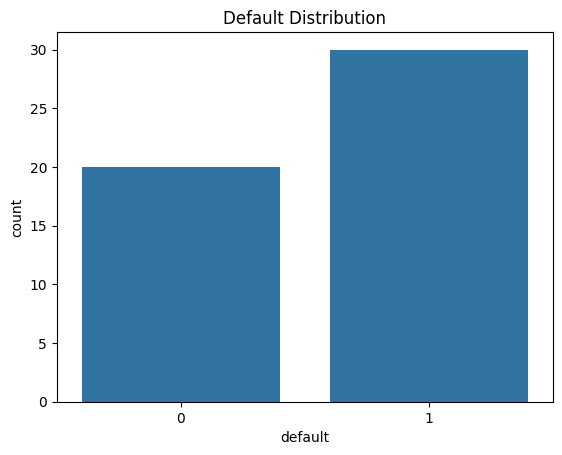

In [9]:
sns.countplot(x='default', data=df)
plt.title("Default Distribution")
plt.show()

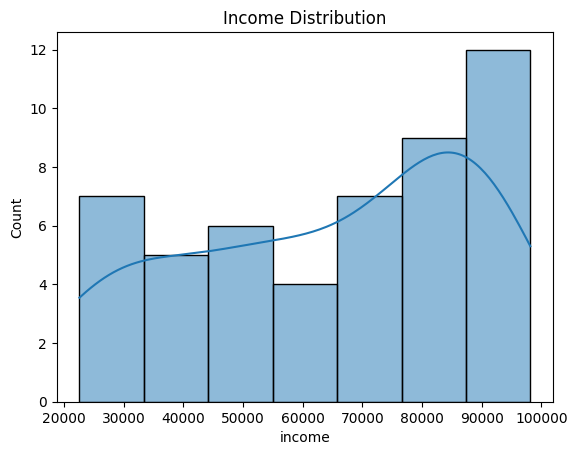

In [10]:
sns.histplot(df['income'], kde=True)
plt.title("Income Distribution")
plt.show()

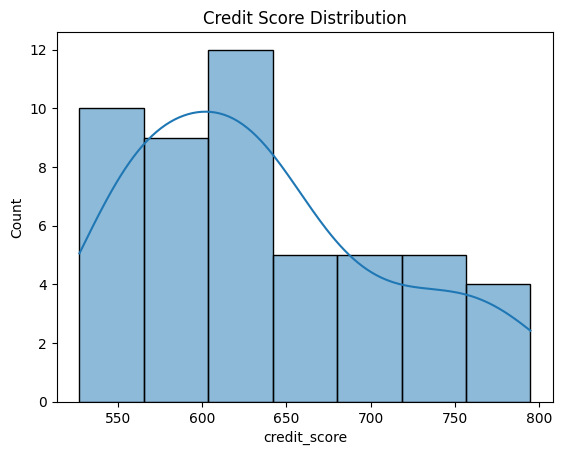

In [11]:
sns.histplot(df['credit_score'], kde=True)
plt.title("Credit Score Distribution")
plt.show()

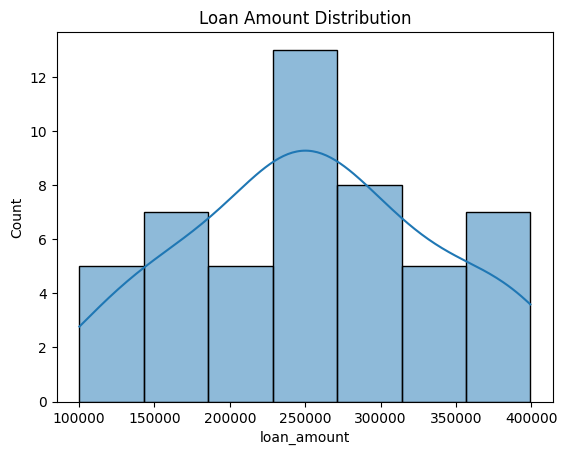

In [12]:
sns.histplot(df['loan_amount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

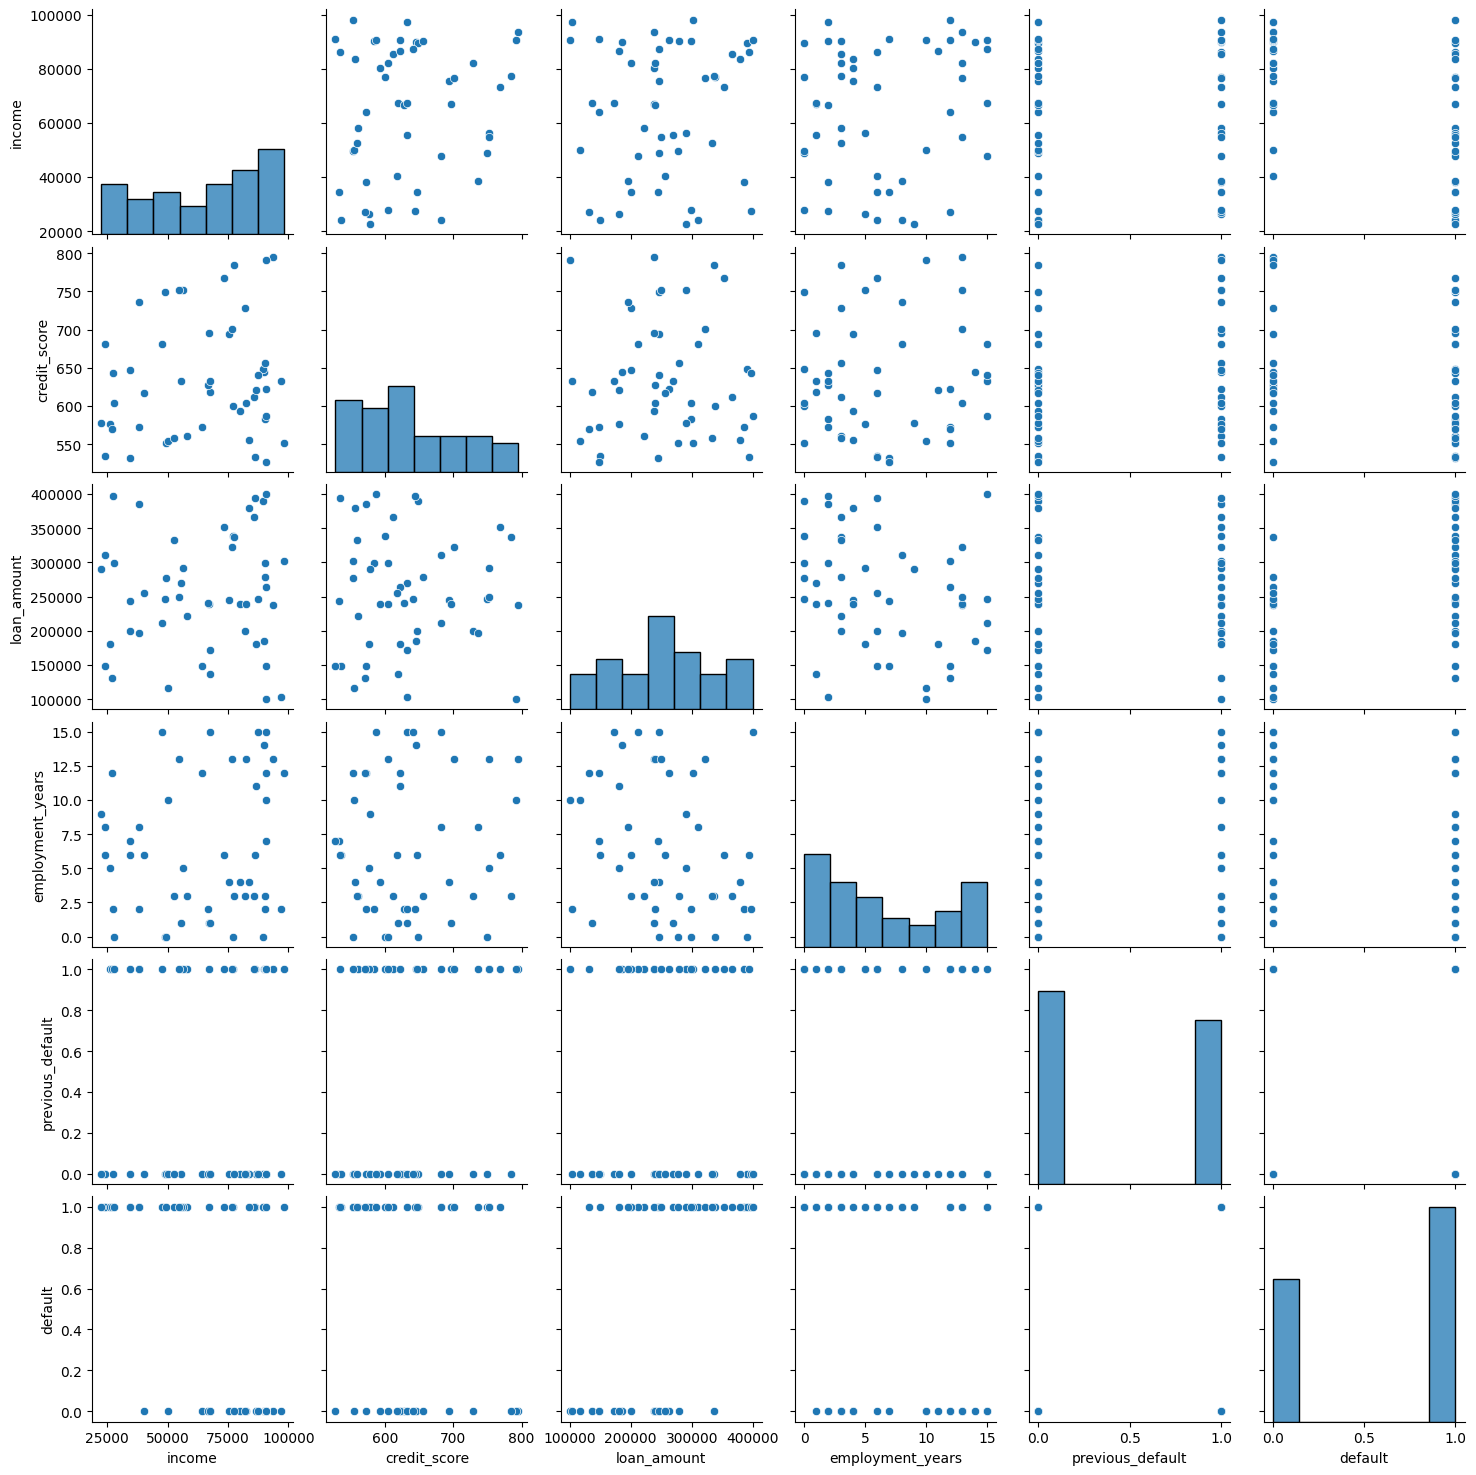

In [13]:
sns.pairplot(df)
plt.show()

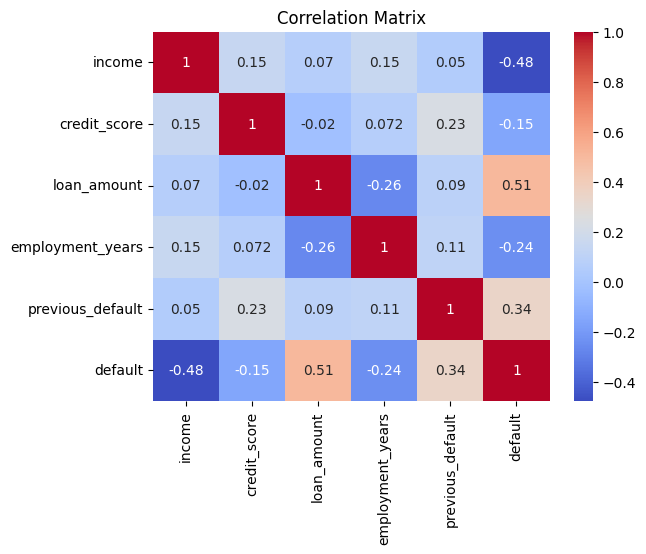

In [14]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [15]:
X = df.drop("default", axis=1)
y = df["default"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, lr_pred))

LR Accuracy: 0.9


In [19]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
print("DT Accuracy:", accuracy_score(y_test, dt_pred))

DT Accuracy: 1.0


In [20]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, rf_pred))

RF Accuracy: 1.0


In [21]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

/opt/anaconda3/envs/loan-env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5312 - loss: 0.8325 - val_accuracy: 0.6250 - val_loss: 0.6957
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5625 - loss: 0.7596 - val_accuracy: 0.6250 - val_loss: 0.6867
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5000 - loss: 0.7295 - val_accuracy: 0.6250 - val_loss: 0.6779
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5625 - loss: 0.7371 - val_accuracy: 0.6250 - val_loss: 0.6699
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4688 - loss: 0.8113 - val_accuracy: 0.6250 - val_loss: 0.6621
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4375 - loss: 0.7282 - val_accuracy: 0.6250 - val_loss: 0.6537
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6250 - loss: 0.7125 - val_accuracy: 0.6250 - val_loss: 0.6459
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5000 - loss: 0.6928 - val_accuracy: 0.6250 - val_loss: 0.6386


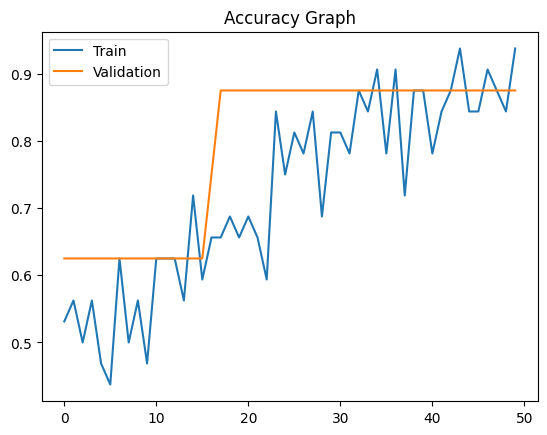

In [24]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Accuracy Graph")
plt.show()

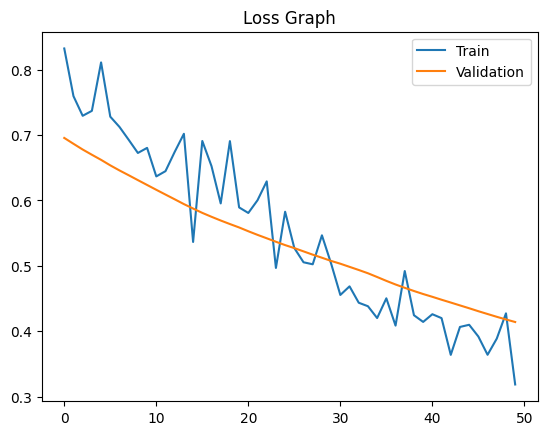

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title("Loss Graph")
plt.show()

In [26]:
loss, acc = model.evaluate(X_test, y_test)
print("ANN Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9000 - loss: 0.4006
ANN Accuracy: 0.8999999761581421


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


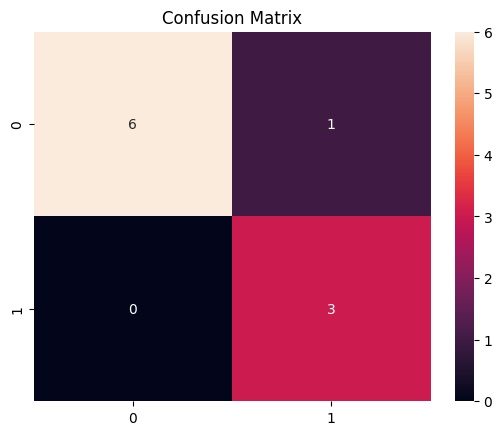

In [27]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.75      1.00      0.86         3

    accuracy                           0.90        10
   macro avg       0.88      0.93      0.89        10
weighted avg       0.93      0.90      0.90        10



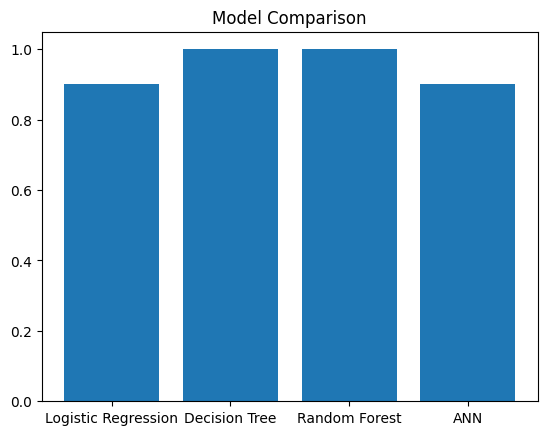

In [28]:
print(classification_report(y_test, y_pred))

models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'ANN']
scores = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred),
    acc
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.show()